In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tabulate import tabulate
layers = tf.keras.layers

The code block below defines a few helper functions to visualize the results. You do not need to touch them.

In [2]:
def plot_examples(X, Y, n=10):
    """ Plot the first n examples for each of the 10 classes in the CIFAR dataset X, Y """
    fig, axes = plt.subplots(n, 10, figsize=(10, n))
    for l in range(10):
        axes[0, l].set_title(cifar10_labels[l], fontsize="smaller")
        m = np.squeeze(Y) == l  # boolean mask: True for all images of label l
        for i in range(n):
            image = X[m][i].astype("uint8")  # imshow expects uint8
            ax = axes[i, l]
            ax.imshow(image, origin="upper")
            ax.set(xticks=[], yticks=[])
    return fig, ax


def plot_prediction(X, Y, Y_predict):
    """
    Plot image X along with predicted probabilities Y_predict.
    X: CIFAR image, shape = (32, 32, 3)
    Y: CIFAR label, one-hot encoded, shape = (10)
    Y_predict: predicted probabilities, shape = (10)
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

    # plot image
    ax1.imshow(X.astype("uint8"), origin="upper")
    ax1.set(xticks=[], yticks=[])

    # plot probabilities
    ax2.barh(np.arange(10), Y_predict, align="center")
    ax2.set(xlim=(0, 1), xlabel="Score", yticks=[])
    for i in range(10):
        c = "red" if (i == np.argmax(Y)) else "black"
        ax2.text(0.05, i, cifar10_labels[i].capitalize(), ha="left", va="center", color=c)



def plot_confusion(Y_true, Y_predict):
    """
    Plot confusion matrix
    Y_true:    array of true classifications (0-9), shape = (N)
    Y_predict: array of predicted classifications (0-9), shape = (N)
    """
    C = np.histogram2d(Y_true, Y_predict, bins=np.linspace(-0.5, 9.5, 11))[0]
    Cn = C / np.sum(C, axis=1)

    fig = plt.figure()
    plt.imshow(Cn, interpolation="nearest", vmin=0, vmax=1, cmap=plt.cm.YlGnBu)
    plt.colorbar()
    plt.xlabel("prediction")
    plt.ylabel("truth")
    plt.xticks(range(10), cifar10_labels, rotation="vertical")
    plt.yticks(range(10), cifar10_labels)
    for x in range(10):
        for y in range(10):
            plt.annotate("%i" % C[x, y], xy=(y, x), ha="center", va="center")



First we load and preprocess CIFAR-10 data. The imagages are 32x32 pixels and have three color channels (red, green blue).

In [3]:

# X: images, Y: labels
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("images, shape = ", x_train.shape)
print("labels, shape = ", y_train.shape)

cifar10_labels = np.array([
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'])

images, shape =  (50000, 32, 32, 3)
labels, shape =  (50000, 1)


/opt/anaconda3/envs/mainenv/lib/python3.13/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


(<Figure size 1000x1000 with 100 Axes>, <Axes: >)

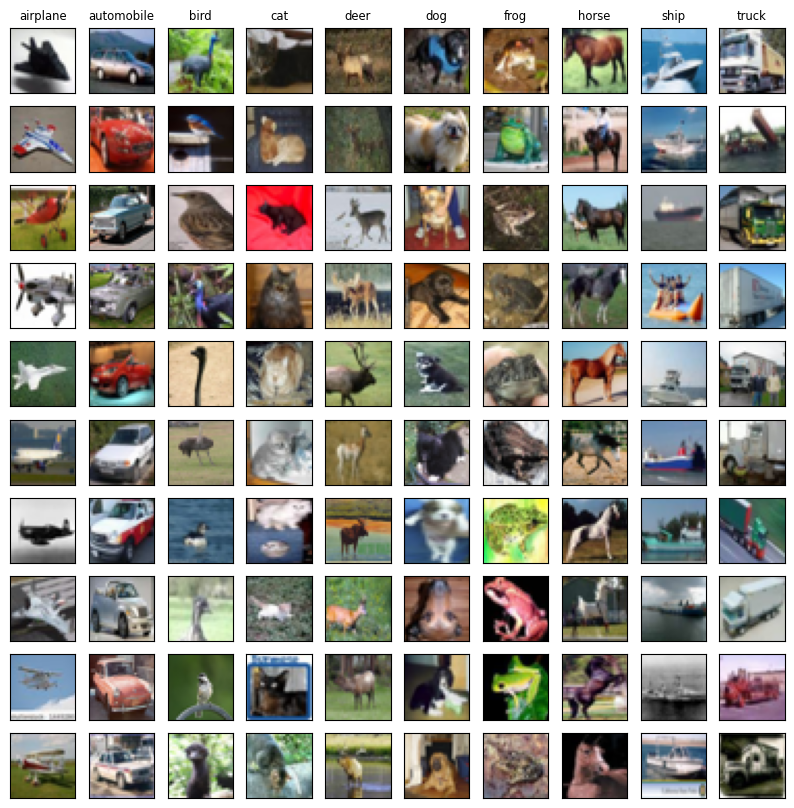

In [4]:
# Hint: To plot example images, you can use the plot examples function
plot_examples(x_train, y_train)

In [7]:
# convert labels ("0"-"9") to one-hot encodings, "0" = (1, 0, ... 0) and so on
y_train_onehot = tf.keras.utils.to_categorical(y_train, 10)
y_test_onehot = tf.keras.utils.to_categorical(y_test, 10)[:8000]
y_valid_onehot = tf.keras.utils.to_categorical(y_test, 10)[8000:]

# Hint: normalize the data
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test[:8000].astype('float32') / 255.0
x_valid_norm = x_test[8000:].astype('float32') / 255.0
# Hint: use 20% of the test data for validation


We start with a fully connected network (two hidden layers of 256 nodes each, and a dropout layer between them)

In [8]:
# ----------------------------------------------------------
# Define model
# ----------------------------------------------------------
model = tf.keras.models.Sequential(
    [
        layers.Flatten(input_shape=(32, 32, 3)),  # (32,32,3) --> (3072)
        # this time the flatten operation is directly integrated into the network
        # structure so that we can use the same input data later for a convolutional neural network.
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
        # Hint: remember that the output layer should have 10 nodes with a softmax activation
    ],
    name="nn",
)

print(model.summary())

Model: "nn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 855,050 (3.26 MB)

 Trainable params: 855,050 (3.26 MB)

 Non-trainable params: 0 (0.00 B)

None


Bottleneck network because reducing parameters aggressively

In [9]:
# ----------------------------------------------------------
# Training
# ----------------------------------------------------------
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    x_train_norm, y_train_onehot,
    batch_size=128,
    epochs=20, # train at least for 20 epochs
    verbose=2,
    validation_data=(x_valid_norm, y_valid_onehot),
    callbacks=[tf.keras.callbacks.CSVLogger("history_{}.csv".format(model.name))],
)

Epoch 1/20
391/391 - 3s - 6ms/step - accuracy: 0.2264 - loss: 2.0762 - val_accuracy: 0.3085 - val_loss: 1.9131
Epoch 2/20
391/391 - 2s - 5ms/step - accuracy: 0.2546 - loss: 2.0001 - val_accuracy: 0.2920 - val_loss: 1.9896
Epoch 3/20
391/391 - 2s - 5ms/step - accuracy: 0.2684 - loss: 1.9554 - val_accuracy: 0.3145 - val_loss: 1.9249
Epoch 4/20
391/391 - 2s - 5ms/step - accuracy: 0.2731 - loss: 1.9444 - val_accuracy: 0.3230 - val_loss: 1.9132
Epoch 5/20
391/391 - 2s - 5ms/step - accuracy: 0.2863 - loss: 1.9175 - val_accuracy: 0.3395 - val_loss: 1.8897
Epoch 6/20
391/391 - 2s - 5ms/step - accuracy: 0.2951 - loss: 1.9035 - val_accuracy: 0.3260 - val_loss: 1.9320
Epoch 7/20
391/391 - 2s - 5ms/step - accuracy: 0.3008 - loss: 1.8929 - val_accuracy: 0.3275 - val_loss: 1.9265
Epoch 8/20
391/391 - 2s - 5ms/step - accuracy: 0.3072 - loss: 1.8796 - val_accuracy: 0.3560 - val_loss: 1.8829
Epoch 9/20
391/391 - 2s - 5ms/step - accuracy: 0.3092 - loss: 1.8754 - val_accuracy: 0.3435 - val_loss: 1.8904
E

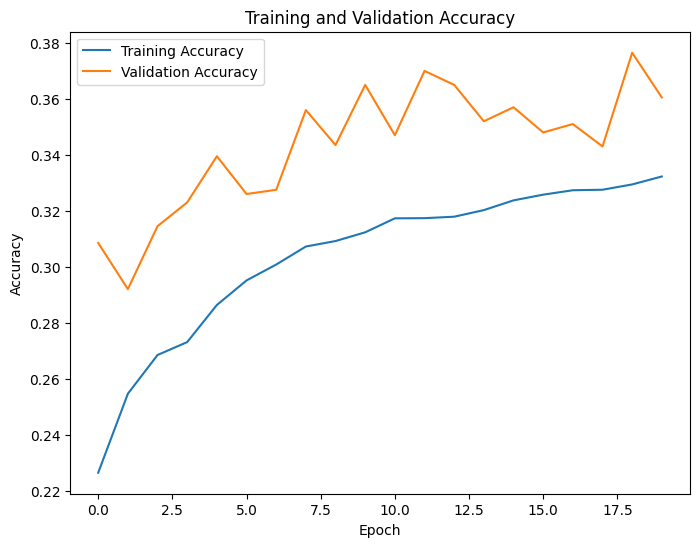

Training Accuracy: 0.3656
Validation Accuracy: 0.3605
Test Accuracy: 0.3659
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


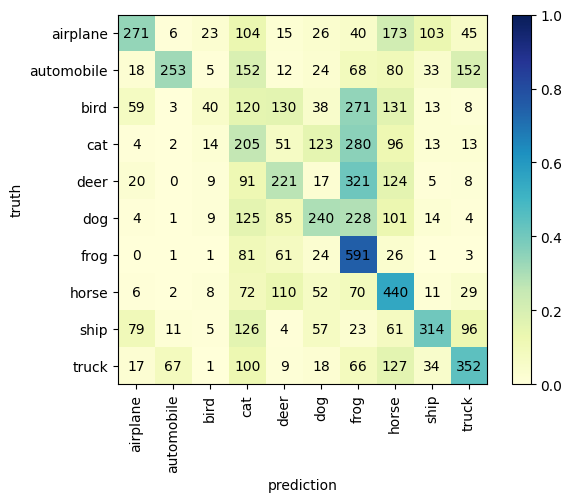

In [10]:
# ----------------------------------------------------------
# Plots
# ----------------------------------------------------------
# training curves
history = np.genfromtxt("history_{}.csv".format(model.name), delimiter=",", names=True)
plt.figure(figsize=(8, 6))
plt.plot(history['epoch'], history['accuracy'], label='Training Accuracy')
plt.plot(history['epoch'], history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

# Quote accuracies
train_loss, train_acc = model.evaluate(x_train_norm, y_train_onehot, verbose=0)
val_loss, val_acc = model.evaluate(x_valid_norm, y_valid_onehot, verbose=0)
test_loss, test_acc = model.evaluate(x_test_norm, y_test_onehot, verbose=0)
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Hint: this is how you can plot the confusion matrix.
# calculate predictions for test set
y_predict = model.predict(x_test_norm, batch_size=128)

# convert back to class labels (0-9)
y_predict_cl = np.argmax(y_predict, axis=1)
y_test_cl = np.argmax(y_test_onehot, axis=1)

# plot confusion matrix
plot_confusion(y_test_cl, y_predict_cl)

Ther are so many misclassified image with fully connected neural network

---------uncorrectly classified----------------


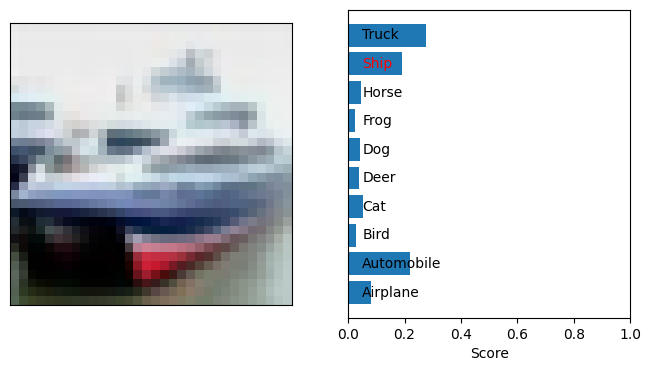

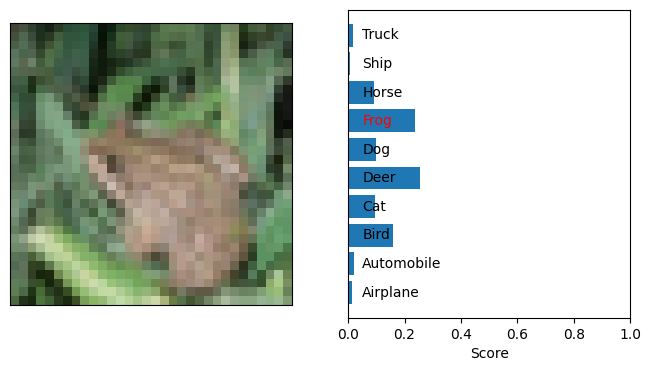

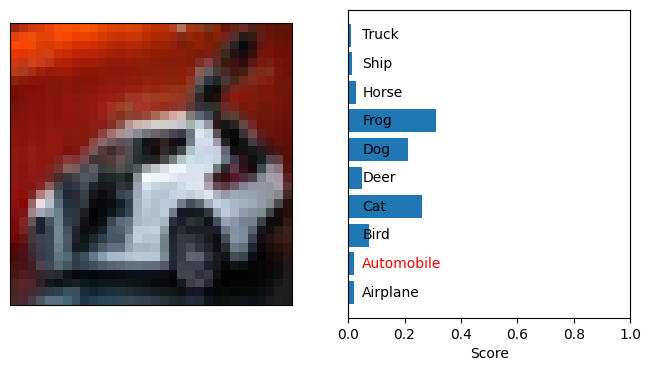

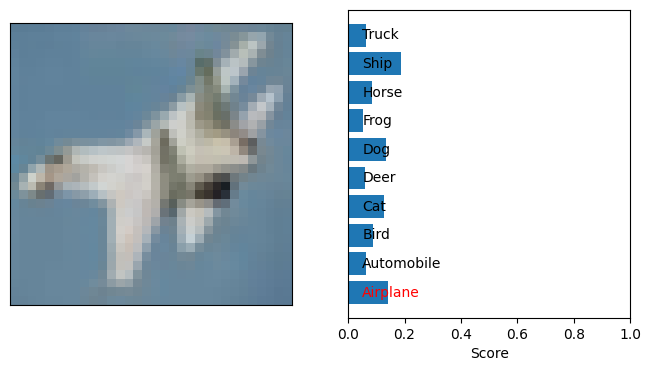

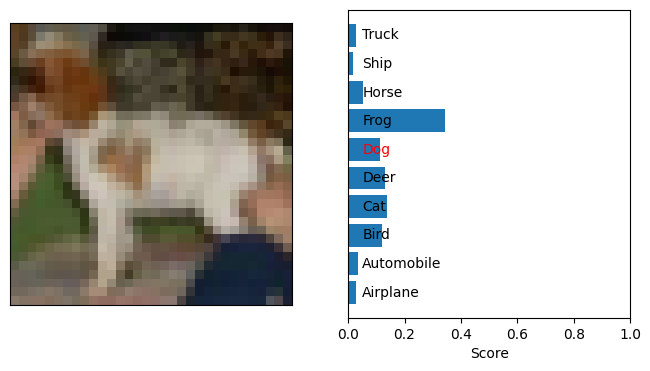

In [11]:
# Task: plot a few examples of correctly and incorrectly classified images.
# Hint: First find the indices of correctly and incorrectly classified images:
m = y_predict_cl == y_test_cl
i0 = np.arange(8000)[~m]  # misclassified images
i1 = np.arange(8000)[m]  # correctly classified images

# original (unnormalized) test images
x_test_ori = x_test[:8000]

# Hint: Now you can use the `plot_prediction` function to plot the images:
print("---------uncorrectly classified----------------")
# plot first 5 false classifications
for i in i0[0:5]:
    plot_prediction(x_test_ori[i], y_test_onehot[i], y_predict[i])


---------correctly classified----------------


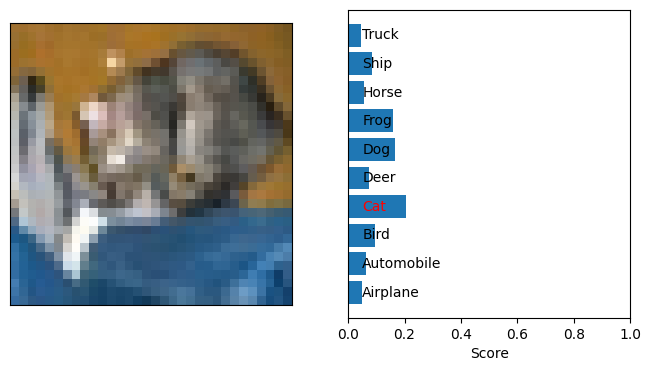

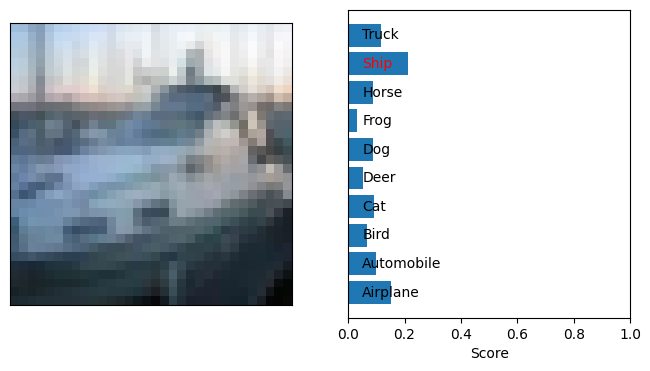

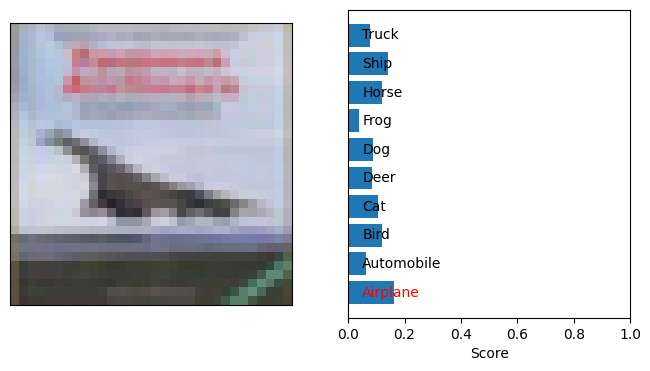

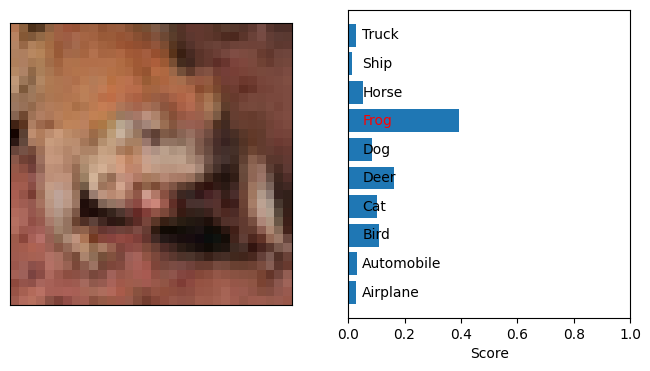

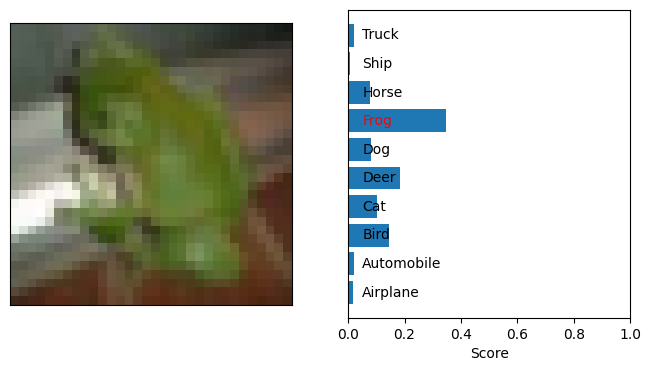

In [12]:

print("---------correctly classified----------------")
#plot first 5 corrected classifications
for i in i1[0:5]:
    plot_prediction(x_test_ori[i], y_test_onehot[i], y_predict[i])

The distribution of the score shown that the low performance of fully connected network for image classification

**CNN**
In the second part of this exercise, classify the images with a CNN.


In [13]:
# Hint: this code snipped shows how to define convolution and maxpooling layers. For more information see
# https://keras.io/api/layers/convolution_layers/convolution2d/
# https://keras.io/api/layers/pooling_layers/max_pooling2d/
model = tf.keras.models.Sequential(
    [
        layers.Conv2D(16, kernel_size=(3, 3), padding="same", activation="relu", input_shape=(32, 32, 3)),
        layers.MaxPooling2D(pool_size=(2,2), strides=(2,2)),
        layers.Conv2D(32, kernel_size=(3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)), # add additional convolution layer and max pooling layer here,
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(10, activation="softmax") # add dropout and output layer
    ],
    name="cnn",
)

print(model.summary())

/opt/anaconda3/envs/mainenv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │        20,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,578 (99.91 KB)

 Trainable params: 25,578 (99.91 KB)

 Non-trainable params: 0 (0.00 B)

None


In [14]:
# ----------------------------------------------------------
# Training
# ----------------------------------------------------------
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.fit(
    x_train_norm, y_train_onehot,
    batch_size=128,
    epochs=40,
    validation_data=(x_valid_norm, y_valid_onehot),
    callbacks=[tf.keras.callbacks.CSVLogger("history_{}.csv".format(model.name))],
)

Epoch 1/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.3844 - loss: 1.7112 - val_accuracy: 0.4780 - val_loss: 1.4474
Epoch 2/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.4920 - loss: 1.4267 - val_accuracy: 0.5195 - val_loss: 1.3263
Epoch 3/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.5303 - loss: 1.3254 - val_accuracy: 0.5610 - val_loss: 1.2309
Epoch 4/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.5582 - loss: 1.2552 - val_accuracy: 0.5850 - val_loss: 1.1934
Epoch 5/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.5786 - loss: 1.2040 - val_accuracy: 0.5880 - val_loss: 1.1630
Epoch 6/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.5920 - loss: 1.1598 - val_accuracy: 0.6180 - val_loss: 1.1078
Epoch 7/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.6024 - loss: 1.1344 - val_accuracy: 0.6305 - val_loss: 1.0618
Epoch 8/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.6157 - loss: 1.1074 - val_accu

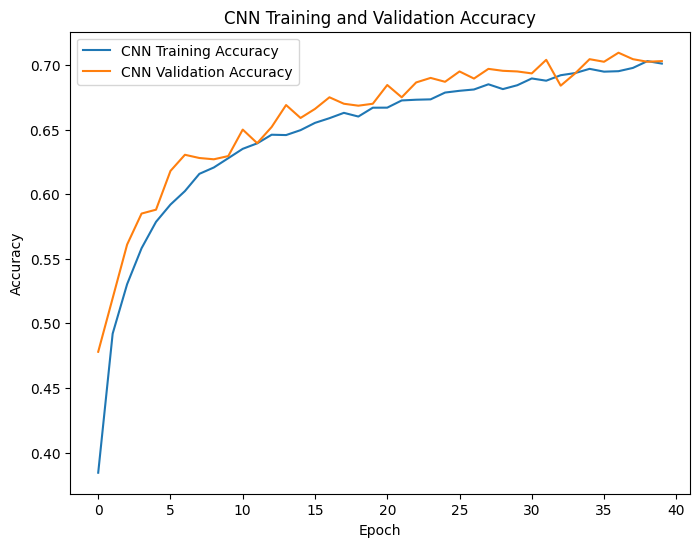

In [15]:
# ----------------------------------------------------------
# CNN Plots & Evaluation
# ----------------------------------------------------------
history_cnn = np.genfromtxt("history_{}.csv".format(model.name), delimiter=",", names=True)
# Plot accuracy vs epoch
plt.figure(figsize=(8, 6))
plt.plot(history_cnn['epoch'], history_cnn['accuracy'], label='CNN Training Accuracy')
plt.plot(history_cnn['epoch'], history_cnn['val_accuracy'], label='CNN Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN Training and Validation Accuracy')
plt.legend()
plt.show()

In [16]:
# Quote accuracies
train_loss_cnn, train_acc_cnn = model.evaluate(x_train_norm, y_train_onehot, verbose=0)
val_loss_cnn, val_acc_cnn = model.evaluate(x_valid_norm, y_valid_onehot, verbose=0)
test_loss_cnn, test_acc_cnn = model.evaluate(x_test_norm, y_test_onehot, verbose=0)
print(f"CNN Training Accuracy: {train_acc_cnn:.4f}")
print(f"CNN Validation Accuracy: {val_acc_cnn:.4f}")
print(f"CNN Test Accuracy: {test_acc_cnn:.4f}")

CNN Training Accuracy: 0.7602
CNN Validation Accuracy: 0.7030
CNN Test Accuracy: 0.7194


The CNN accuracy is higher than the nn's

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


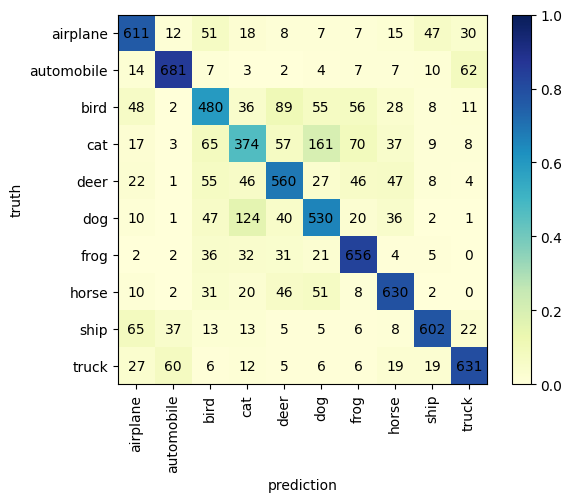

In [17]:
# Calculate predictions
y_predict_cnn = model.predict(x_test_norm, batch_size=128)
y_predict_cl_cnn = np.argmax(y_predict_cnn, axis=1)
# Plot confusion matrix
plot_confusion(y_test_cl, y_predict_cl_cnn)
plt.show()


CNN Correctly classified examples:


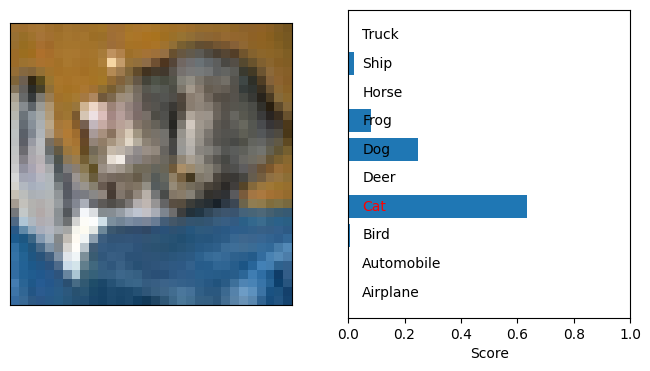

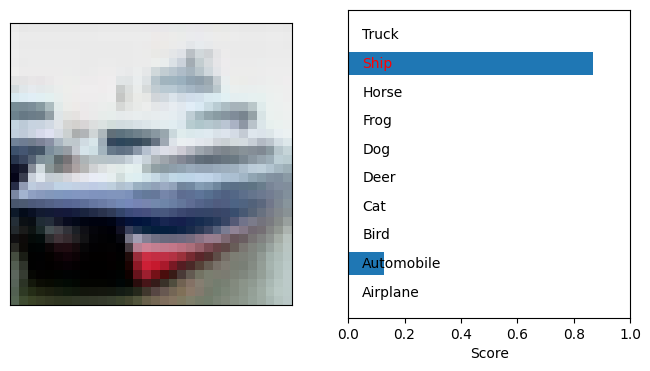

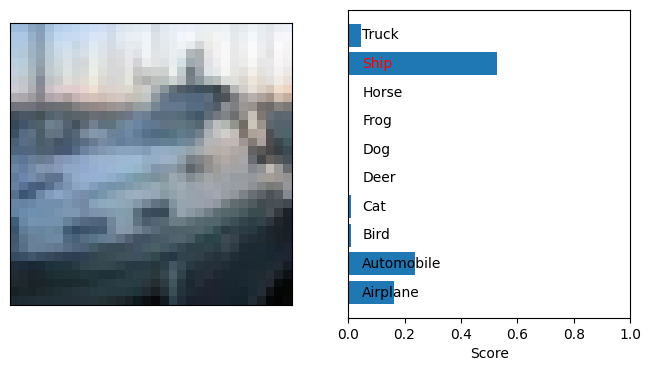

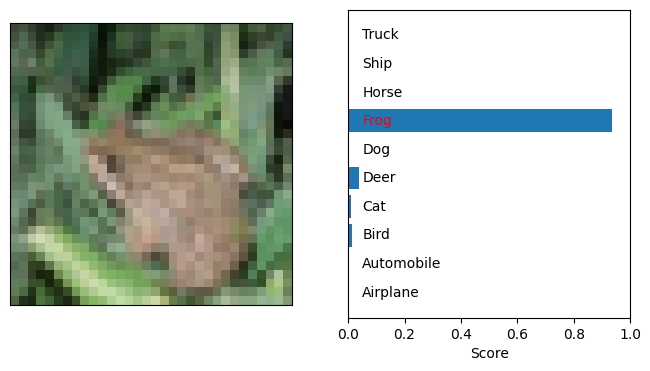

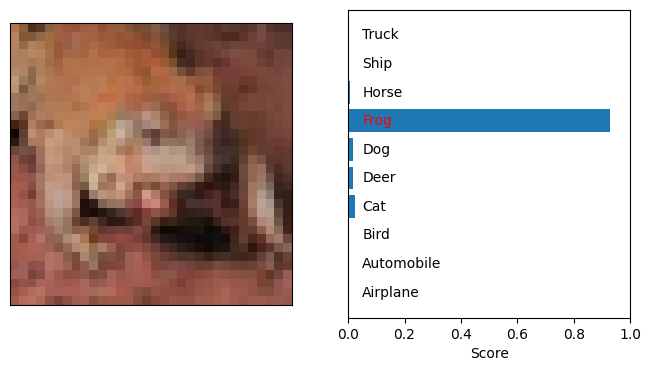

In [19]:
# Predictions visualizations
m_cnn = y_predict_cl_cnn == y_test_cl
i0_cnn = np.arange(8000)[~m_cnn]  # misclassified
i1_cnn = np.arange(8000)[m_cnn]   # correctly classified
print("CNN Correctly classified examples:")
for i in i1_cnn[0:5]:
    plot_prediction(x_test_ori[i], y_test_onehot[i], y_predict_cnn[i])
plt.show()

CNN Incorrectly classified examples:


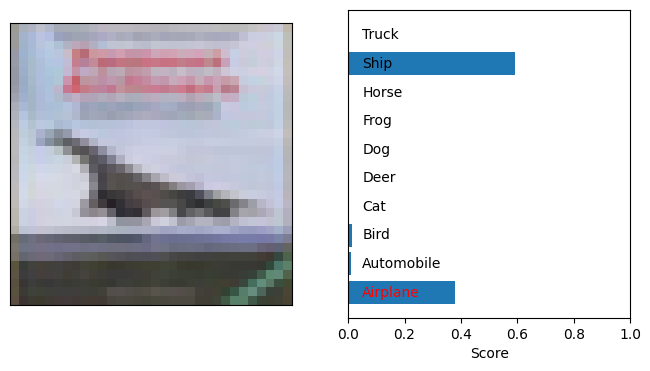

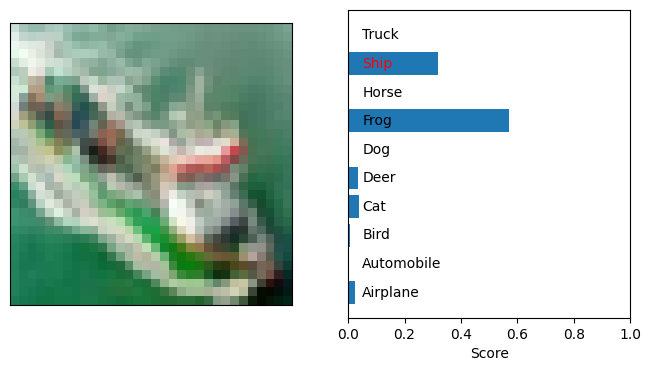

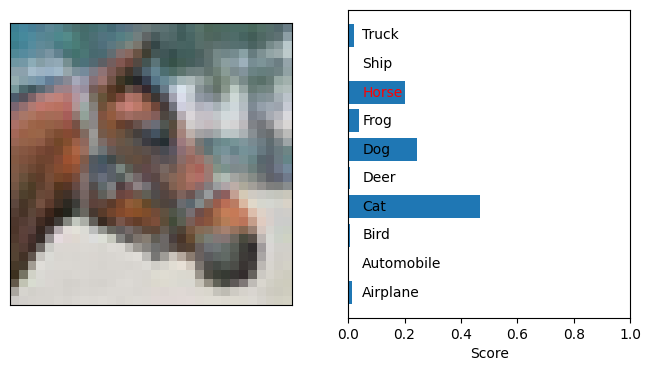

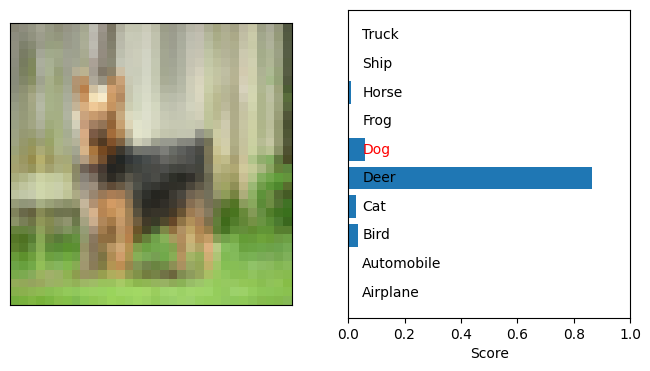

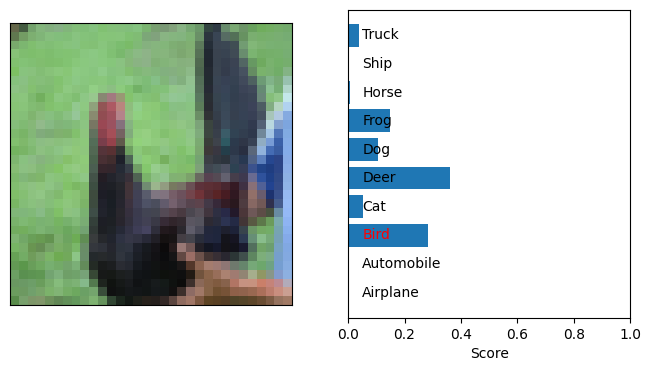

In [20]:
print("CNN Incorrectly classified examples:")
for i in i0_cnn[0:5]:
    plot_prediction(x_test_ori[i], y_test_onehot[i], y_predict_cnn[i])
plt.show()

The CNN performance give better classification compared with fully connected network. Althrough there are some misclassified.